# FMR of a layer with PMA
Ferromagnetic resonance (FMR) is a standard technique to measure the magnetic properties of a material. It is often simple when no anisotropies are present, but can become more complex when the material has some anisotropy. This example notebook shows how to use the SpinWaveToolkit to calculate the FMR of a layer with perpendicular magnetic anisotropy (PMA). The notebook demonstrates how to set up the calculation for simple modeling and use SpinWaveToolkit for fitting experimental data.

In this example we assume a thin film made of bismuth-doped yttrium iron garnet (Bi:YIG), which is a ferrimagnetic material often used in magnonics. We will assume the PMA is strong enough to overcome the shape anisotropy at zero magnetic field. We will sweep the external magnetic field in the plane of the film and see how the FMR frequency changes with the applied field.

First we import the required modules and define the material parameters.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import SpinWaveToolkit as SWT
from tqdm import tqdm

In [5]:
# material definition
biyig = SWT.Material(
    Ms=110e3,  # (A/m) saturation magnetization
    Aex=2.88e-12,  # (J/m) exchange stiffness
    alpha=1e-4,  # () Gilbert damping
    gamma=28*2e9*np.pi,  # (rad/s/T) gyromagnetic ratio
)
d = 70e-9  # (m) thickness of the layer
Ku = 15e3  # (J/m^3) uniaxial anisotropy constant
print(f"anisotropy field: mu0*Hani = 2*Ku/(biyig.Ms) = {2*Ku/(biyig.Ms):.4} T")

anisotropy field: mu0*Hani = 2*Ku/(biyig.Ms) = 0.2727 T


## Field sweep definition and macrospin instatiation
In our calculations, we will work in the macrospin approximation. This is handled by the `MacrospinEquilibrium` class, which calculates the equilibrium magnetization direction for a given applied field and material parameters as well as anisotropies.

The applied magnetic field will start at saturation and sweep down to zero.

In [6]:
nb = 100
bexts = np.linspace(0.5, 1e-4, nb)  # (T) applied field sweep from high to low
maceq = SWT.MacrospinEquilibrium(
    Ms=biyig.Ms,
    Bext=bexts[0], theta_H=np.pi/2, phi_H=0,  # initial field direction (in-plane along x-axis)
)
maceq.add_uniaxial_anisotropy("PMA", Ku=Ku, theta=0, phi=0)  # add PMA along z-axis

# sweep the applied field in-plane along x-axis -> magnetization angles at each point
theta, phi = maceq.hysteresis(Bext=bexts, theta_H=np.pi/2, phi_H=0)

# optionally, we can look at the effective field (currently, no helper function for this)
beffs = np.zeros(nb)
for i in tqdm(range(nb), ascii=True, ncols=80):
    maceq.Bext["Bext"] = bexts[i]
    maceq.minimize(verbose=False)
    beffs[i] = maceq.getHeff()[2]  # returns also angles same as theta and phi

100%|#########################################| 100/100 [00:01<00:00, 78.32it/s]


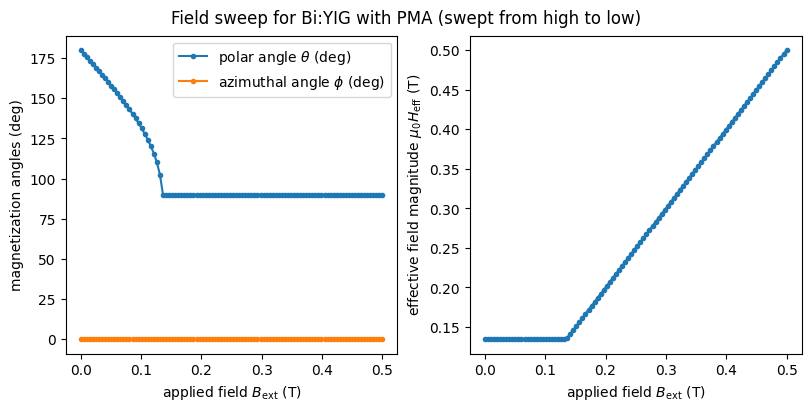

In [7]:
# plot the magnetization angles and Heff as a function of applied field
fig, ax = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
ax[0].plot(bexts, theta*180/np.pi, ".-", label=r'polar angle $\theta$ (deg)')
ax[0].plot(bexts, SWT.wrapAngle(phi+1e-6)*180/np.pi, # small offset to avoid wrapping artifacts
           ".-", label=r'azimuthal angle $\phi$ (deg)')
ax[0].set_xlabel(r'applied field $B_\mathrm{ext}$ (T)')
ax[0].set_ylabel(r'magnetization angles (deg)')
ax[0].legend()
fig.suptitle("Field sweep for Bi:YIG with PMA (swept from high to low)")
ax[1].plot(bexts, beffs, ".-", label=r'$\mu_0 H_\mathrm{eff}$ (T)')
ax[1].set_xlabel(r'applied field $B_\mathrm{ext}$ (T)')
ax[1].set_ylabel(r'effective field magnitude $\mu_0 H_\mathrm{eff}$ (T)')
plt.show()

## Calculation of the dynamic response
Now we use the equilibrium angles calculated from the `MacrospinEquilibrium` class to calculate the dynamic response of the system. For this, we will use the `SingleLayer` class, which can calculate the magnetization dynamics at oblique angles. It is primarily used for calculations of spin wave dispersion relations, but since FMR is technically a spin wave with zero wavevector, it can be easily adapted to our case.

*(Note that `SingleLayer` cannot currently account for higher-order anisotropes — it requires the anisotropy to be expressed as a 3×3 matrix linear with M.)*

In the calculation of frequencies, we use the fact that `SingleLayer` can work with most parameters supplied as arrays. This allows us to calculate the FMR frequencies for all applied fields in one go, which is much faster than calculating them one by one. The only condition is that all parameters supplied as arrays must have the same length as `kxi`.

In [8]:
sl = SWT.SingleLayer(material=biyig, d=d, # material parameters
    Bext=bexts, theta_H=np.pi/2, phi_H=0,  # field values
    theta=theta, phi=phi,  # equilibrium angles from macrospin model
    kxi=np.ones(nb),  # (rad/m) wavevector || x; small k to avoid division by 0
    Na=maceq.Na_tot)  # add anisotropy

n = 3  # number of thickness modes to calculate
freq = np.array(
    [sl.GetDispersion(n=ni) for ni in range(n)]
)/(2e9*np.pi)  # (GHz)

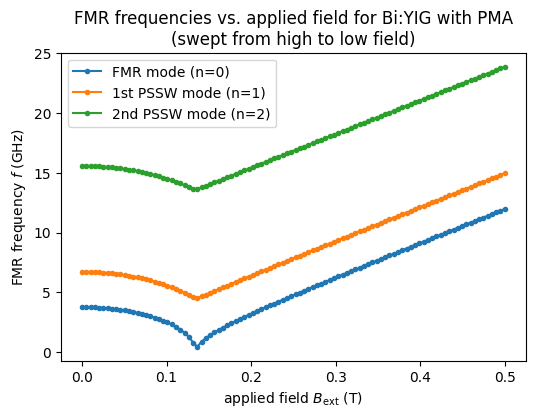

In [9]:
# plot the FMR frequencies as a function of applied field
plt.figure(figsize=(6, 4))
plt.plot(bexts, freq[0, :], ".-", label="FMR mode (n=0)")
plt.plot(bexts, freq[1, :], ".-", label="1st PSSW mode (n=1)")
plt.plot(bexts, freq[2, :], ".-", label="2nd PSSW mode (n=2)")
plt.xlabel(r'applied field $B_\mathrm{ext}$ (T)')
plt.ylabel(r'FMR frequency $f$ (GHz)')
plt.legend()
plt.title("FMR frequencies vs. applied field for Bi:YIG with PMA"
          +"\n(swept from high to low field)")
plt.show()

## Fitting experimental data

We will now take the previously calculated FMR frequencies and assume they come from experiment. Next we demonstrate how to use the same models as described above to fit the material parameters.

TODO:
1. prepare fitting procedure
2. perform fit and show results

In [10]:
from scipy.optimize import curve_fit

# define fitting function
def fmr_fit_func(_Bext, _Ms, _Ku, _Aex):
    """Our custom fitting function.
    Bext - ndarray; (T) applied field values.
    _Ms, _Ku, _Aex - float; (SI units) fitting parameters.
    """
    _Bext = np.array(_Bext)  # due to curve_fit has to have same length as output
    # fixed parameters
    _nmodes = 3
    _d = 70e-9  # (m) thickness of the layer

    _nb = len(_Bext)//_nmodes  # number of applied field points per mode
    _bext = _Bext[:_nb]  # applied field values for one mode
    # create a new material with the fitting parameters
    _mat = SWT.Material(Ms=_Ms, Aex=_Aex, alpha=biyig.alpha, gamma=biyig.gamma)
    _me = SWT.MacrospinEquilibrium(
        Ms=_Ms, verbose=False,
        Bext=_bext[0], theta_H=np.pi/2, phi_H=0,  # initial state; Bext || x
    )
    _me.add_uniaxial_anisotropy("PMA", Ku=_Ku, theta=0, phi=0)  # add PMA || z
    _theta, _phi = _me.hysteresis(Bext=_bext, theta_H=np.pi/2, phi_H=0)
    # create a new SingleLayer object with the fitting parameters
    sl = SWT.SingleLayer(
        material=_mat, d=_d, theta=_theta, phi=_phi, Bext=_bext,
        theta_H=np.pi/2, phi_H=0, kxi=np.ones(nb), Na=_me.Na_tot,
    )
    # calculate the FMR frequency (GHz) for each Bext and thickness mode
    _f = np.array([sl.GetDispersion(n=ni)/(2e9*np.pi) for ni in range(_nmodes)])
    return _f.ravel()  # flatten the array to 1D for curve_fit

In [11]:
# perform fit
p0 = [100e3, 12e3, 3e-12]  # initial guess for Ms, Ku, Aex
bounds = ([50e3, 5, 2e-12], [200e3, 20e3, 4e-12])  # bounds for Ms, Ku, Aex
bext_fit = np.tile(bexts, 3)  # repeat the applied field values for each mode
popt, pcov = curve_fit(fmr_fit_func, bext_fit, freq.ravel(), p0=p0,
                       bounds=bounds)
perr = np.sqrt(np.diag(pcov))  # standard deviation of the parameters
print(f"Fitted parameters:\nMs = {popt[0]:.2e} ± {perr[0]:.2e} A/m\n"
      f"Ku = {popt[1]:.2e} ± {perr[1]:.2e} J/m^3\n"
      f"Aex = {popt[2]:.2e} ± {perr[2]:.2e} J/m\n")
print(f"Original parameters:\nMs = {biyig.Ms:.2e} A/m\n"
      f"Ku = {Ku:.2e} J/m^3\nAex = {biyig.Aex:.2e} J/m")

100%|#########################################| 100/100 [00:01<00:00, 79.11it/s]

Fitted parameters:
Ms = 1.02e+05 ± 7.14e-39 A/m
Ku = 1.35e+04 ± 1.02e-37 J/m^3
Aex = 2.68e-12 ± 3.07e-22 J/m

Original parameters:
Ms = 1.10e+05 A/m
Ku = 1.50e+04 J/m^3
Aex = 2.88e-12 J/m


100%|#########################################| 100/100 [00:01<00:00, 74.49it/s]


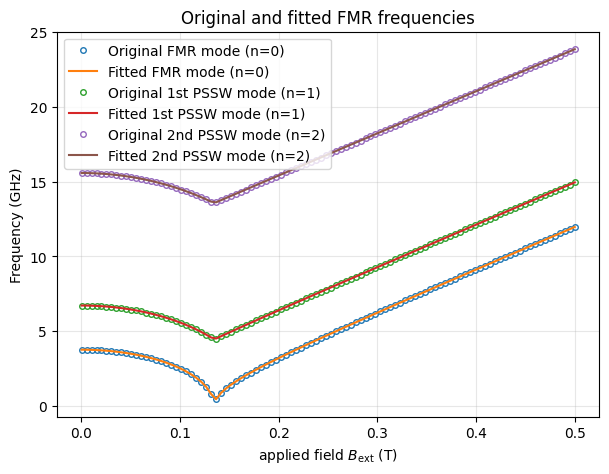

In [12]:
# Calculate frequencies using the fitted parameters
freq_fit = fmr_fit_func(bext_fit, *popt).reshape(n, nb)

fig, ax = plt.subplots(figsize=(7, 5))

labels = ["FMR mode (n=0)", "1st PSSW mode (n=1)", "2nd PSSW mode (n=2)"]
for mode, label in enumerate(labels):
    ax.plot(bexts, freq[mode], "o", ms=4, mfc="none", label=f"Original {label}")
    ax.plot(bexts, freq_fit[mode], "-", lw=1.5, label=f"Fitted {label}")

ax.set_xlabel(r"applied field $B_\mathrm{ext}$ (T)")
ax.set_ylabel("Frequency (GHz)")
ax.set_title("Original and fitted FMR frequencies")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

The results quite differ from the original even though the plot seems very similar. This is because the anisotropy strength is coupled with the saturation magnetization which is slightly coupled to the exchange stiffness. Having known the saturation magnetization from other measurements, e.g. a vibrating sample magnetometer (VSM), we can fix the saturation magnetization and only fit the anisotropy strength and exchange stiffness. This should give a more accurate result.

### Fitting only the base mode
If only the base mode is detected in the measurement, we need to know either the saturation magnetization or the anisotropy strength to be able to fit the other parameter. In this case, we will assume that the saturation magnetization is known from other measurements and only fit the anisotropy strength.

If we did not fix one of the parameters, the fit would not be able to converge to a reasonable result.

In [13]:
# define fitting function
def fmr_fit_func_n0(_Bext, _Ku):
    """Our custom fitting function.
    Bext - ndarray; (T) applied field values.
    _Ku - float; (J/m3) anisotropy strength.
    """
    _Bext = np.array(_Bext)  # due to curve_fit has to have same length as output
    # fixed parameters
    _d = 70e-9  # (m) thickness of the layer

    # create a new material with the fitting parameters
    _mat = biyig
    _me = SWT.MacrospinEquilibrium(
        Ms=_mat.Ms, verbose=False,
        Bext=_Bext[0], theta_H=np.pi/2, phi_H=0,  # initial state; Bext || x
    )
    _me.add_uniaxial_anisotropy("PMA", Ku=_Ku, theta=0, phi=0)  # add PMA || z
    _theta, _phi = _me.hysteresis(Bext=_Bext, theta_H=np.pi/2, phi_H=0)
    # create a new SingleLayer object with the fitting parameters
    sl = SWT.SingleLayer(
        material=_mat, d=_d, theta=_theta, phi=_phi, Bext=_Bext,
        theta_H=np.pi/2, phi_H=0, kxi=np.ones(nb), Na=_me.Na_tot,
    )
    # calculate the FMR frequency (GHz) for each Bext and n=0
    return sl.GetDispersion(n=0)/(2e9*np.pi)

In [14]:
# perform fit
p0 = [12e3]  # initial guess for Ku
bounds = ([5], [20e3])  # bounds for Ku
popt, pcov = curve_fit(fmr_fit_func_n0, bexts, freq[0], p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))  # standard deviation of the parameters
print(f"Fitted parameters:\nKu = {popt[0]:.2e} ± {perr[0]:.2e} J/m^3\n")
print(f"Original parameters:\nKu = {Ku:.2e} J/m^3")

100%|#########################################| 100/100 [00:01<00:00, 77.40it/s]

Fitted parameters:
Ku = 1.50e+04 ± 4.03e-06 J/m^3

Original parameters:
Ku = 1.50e+04 J/m^3


100%|#########################################| 100/100 [00:01<00:00, 76.93it/s]


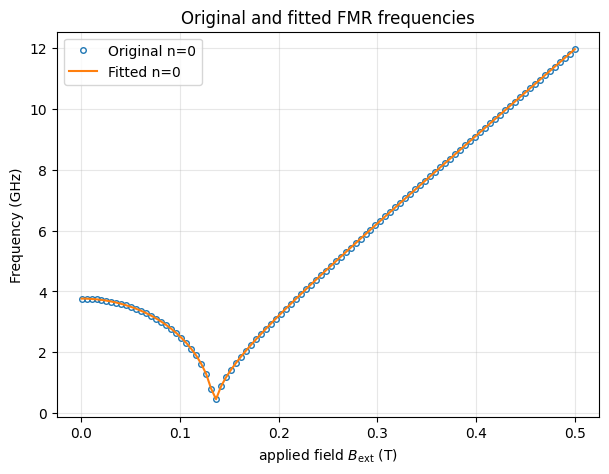

In [15]:
# Calculate frequencies using the fitted parameters
freq_fit = fmr_fit_func_n0(bexts, *popt)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(bexts, freq[0], "o", ms=4, mfc="none", label=f"Original n=0")
ax.plot(bexts, freq_fit, "-", lw=1.5, label=f"Fitted n=0")
ax.set_xlabel(r"applied field $B_\mathrm{ext}$ (T)")
ax.set_ylabel("Frequency (GHz)")
ax.set_title("Original and fitted FMR frequencies")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In this well-condtitioned case, the fitting is very much reliable and the fitted parameter Ku is very close to the original one.